In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
print(df.shape)           # ¿Cuántos clientes, cuántas columnas?
print(df.dtypes)          # ¿Qué tipos de datos tengo?
print(df.isnull().sum())  # ¿Dónde hay huecos?
print(df['Churn'].value_counts(normalize=True))  # ¿Qué % cancela?

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

#Discovery

- Forma de los datos: 7043 filas y 21 columnas
- 18 variables objeto y 3 variables numéricas. La variable 'TotalCharges' aparece como objeto.
- No hay valores faltantes
- El 27% de los clientes cancela



In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors= 'coerce')

In [6]:
print(df['TotalCharges'].isnull().sum())

11


* La variable `'TotalCharges'` era string entonces fue transformada a numérica con `pd.to_numeric()`.

El número de ***valores afectados*** fue de ***11***.


#EDA con preguntas de negocio 💻
* ¿Los clientes con contrato mes a mes cancelan más?
* ¿El tenure (antiguedad) afecta el churn?
* ¿Los que pagan más cancelan más o menos?


In [7]:
df.TotalCharges.describe()

,TotalCharges
count,7032.000000
mean,2283.300441
std,2266.771362
min,18.800000
25%,401.450000
50%,1397.475000
75%,3794.737500
max,8684.800000


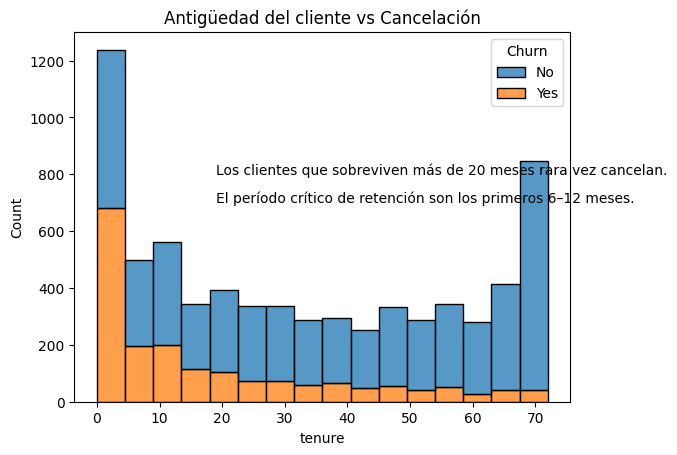

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# ¿Tenure vs Churn?
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack')
plt.title('Antigüedad del cliente vs Cancelación')
plt.show()

# **Entregable real:** 3–5 gráficas con una observación de negocio debajo de cada una. No "el histograma muestra…" sino "los clientes que cancelan tienen en promedio X meses menos de antigüedad, lo que sugiere que los primeros 6 meses son el período crítico de retención."


# Interpretación
Los clientes que sobreviven más de ***20 meses con la empresa** **rara vez cancelan***.

El periodo crítico de retención son los primeros 6 a 12 meses.